In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainstate
import braincell
import matplotlib.pyplot as plt
import numpy as np
import brainunit as u
from braincell import (
    Branch,
    CableProperties,
    Cell,
    CVPerBranch,
    MaxCVLen,
    Morphology,
)
from braincell.filter import BranchSlice, RootLocation, AllRegion

In [2]:
def demo_tree() -> Morphology:
    soma = Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[8.0, 8.0] * u.um,
        type="soma",
    )
    basal = Branch.from_lengths(
        lengths=[30.0] * u.um,
        radii=[2.0, 1.5] * u.um,
        type="basal_dendrite",
    )
    apical = Branch.from_lengths(
        lengths=[50.0] * u.um,
        radii=[2.5, 1.0] * u.um,
        type="apical_dendrite",
    )
    tree = Morphology.from_root(soma, name="soma")
    tree.soma.basal = basal
    tree.soma.apical = apical
    return tree

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


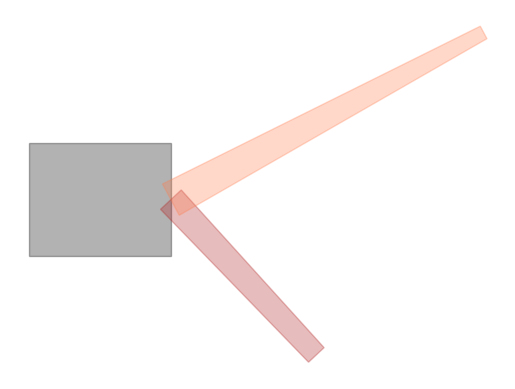

-----------------------------------
root         | soma
n_branches   | 3
geometry     | incomplete 3d points
length       | 100.00 um
area         | 1885.25 um^2
volume       | 4822.34 um^3
-----------------------------------

soma
├── basal
└── apical


In [3]:
demo_tree = demo_tree()
demo_tree.vis2d()
print(demo_tree)
print(demo_tree.topo())

In [ ]:
cell = Cell(demo_tree, cv_policy=CVPerBranch(2))
print(cell)
print(cell.cvs)

In [ ]:
cell.cv_policy = MaxCVLen(15.0 * u.um)
print(cell)
print(cell.cvs)

In [ ]:
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    CableProperties(
        resting_potential=-70.0 * u.mV,
        membrane_capacitance=2.0 * (u.uF / u.cm ** 2),
        axial_resistivity=150.0 * (u.ohm * u.cm),
        temperature=u.celsius2kelvin(30.0),
    ),
)
cell.paint_rules

In [ ]:
tree = braincell.Morphology.from_swc('./morpho_files/bc.swc')
tree.vis3d(jupyter_backend='html')

In [7]:
print(tree.topo())

soma
├── basal_dendrite_0
│   ├── basal_dendrite_1
│   └── basal_dendrite_2
├── basal_dendrite_3
├── basal_dendrite_4
├── basal_dendrite_5
│   ├── basal_dendrite_6
│   └── basal_dendrite_7
│       ├── basal_dendrite_8
│       │   ├── basal_dendrite_9
│       │   └── basal_dendrite_10
│       │       ├── basal_dendrite_11
│       │       └── basal_dendrite_12
│       └── basal_dendrite_13
│           ├── basal_dendrite_14
│           └── basal_dendrite_15
│               ├── basal_dendrite_16
│               └── basal_dendrite_17
│                   ├── basal_dendrite_18
│                   └── basal_dendrite_19
│                       ├── basal_dendrite_20
│                       └── basal_dendrite_21
├── basal_dendrite_22
│   ├── basal_dendrite_23
│   └── basal_dendrite_24
│       ├── basal_dendrite_25
│       └── basal_dendrite_26
├── basal_dendrite_27
│   ├── basal_dendrite_28
│   │   ├── basal_dendrite_29
│   │   └── basal_dendrite_30
│   └── basal_dendrite_31
│       ├── basal_den

In [8]:
cell = Cell(
    tree,
    solver="staggered",
    cv_policy=CVPerBranch(2),
)
cell.paint(
    AllRegion(),
    braincell.mech.Channel("IL", g_max=0.1 * (u.mS / u.cm ** 2), E=-70.0 * u.mV)
)

cell.paint(
    braincell.filter.BranchInFilter('type', 'soma'),
    braincell.mech.Channel("INa_HH1952", g_max=120 * (u.mS / u.cm ** 2)),
    braincell.mech.Channel("IK_HH1952", g_max=36 * (u.mS / u.cm ** 2)),
)

cell.paint(
    braincell.filter.BranchInFilter('type', 'basal_dendrite'),
    braincell.mech.Channel("INa_HH1952", g_max=120 * (u.mS / u.cm ** 2)),
    braincell.mech.Channel("IK_HH1952", g_max=36 * (u.mS / u.cm ** 2)),
)

cell.paint(
    braincell.filter.BranchInFilter('type', 'axon'),
    braincell.mech.Channel("INa_HH1952", g_max=120 * (u.mS / u.cm ** 2)),
    braincell.mech.Channel("IK_HH1952", g_max=36 * (u.mS / u.cm ** 2)),
)

cell.place(
    RootLocation(x=0.5),
    braincell.CurrentClamp(
        start=0.0 * u.ms,
        durations=(50.0 * u.ms, 100.0 * u.ms,),
        amplitudes=(0.0 * u.nA, 0.3 * u.nA,),
    ),
)
cell.init_state()

In [9]:
table = cell.mech_table()
print(table.row_labels)
print(table.column_ids)
print(table.shape)

obj = table.get_by_label("INa_HH1952", 4)
if obj is not None:
    print(obj.declaration)
    print(obj.node)
    print(obj.node.g_max)

for point_id in table.column_ids:
    ina = table.get_by_label("INa_HH1952", point_id)
    ik = table.get_by_label("IK_HH1952", point_id)
    il = table.get_by_label("IL", point_id)

    if ina is not None:
        print("point", point_id, "INa.g_max =", ina.g_max)
    if ik is not None:
        print("point", point_id, "IK.g_max =", ik.g_max)
    if il is not None:
        print("point", point_id, "IL.g_max =", il.g_max)
        print("point", point_id, "IL.E =", il.E)

('IL', 'INa_HH1952', 'IK_HH1952', 'CurrentClamp')
(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211,

In [10]:
dt = 0.1 * u.ms
tstop = 200 * u.ms


def step_fun(t):
    with brainstate.environ.context(t=t):
        cell.update()
    v_next = cell.V.value
    return v_next


cell.reset_state()

with brainstate.environ.context(dt=dt):
    times = u.math.arange(0.0 * u.ms, tstop, brainstate.environ.get_dt())
    v_seq = brainstate.transform.for_loop(step_fun, times)

v_mV = np.asarray(v_seq / u.mV, dtype=float)

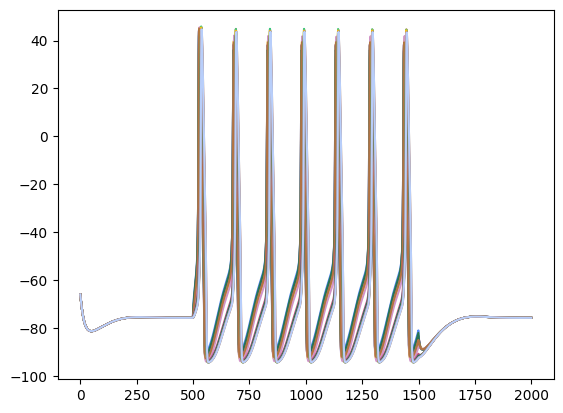

In [11]:
for i in range(200):
    if i % 10 == 0:
        plt.plot(v_mV[:, i])
plt.show()